# Bonus 01 - Regression with MAPIE: the desk-safe wrapper

> "The prototype interval works. Now make it boring enough to maintain." - Hearthstone's engineering lead

Notebook 08 introduced MAPIE on public California housing data. This bonus notebook brings
that library back into the original Hearthstone setting and asks a narrower production
question: can we use MAPIE for the same regression job the desk actually cares about,
while still reading every number like a conformal reviewer?

What you will learn:

- How to reconcile MAPIE's split conformal regressor against the fifteen-line recipe from
  notebook 02 on the same synthetic market.
- Why constant-width intervals are often valid and still operationally clumsy.
- How MAPIE's conformalized quantile regressor turns notebook 05's adaptive-interval idea
  into a library call.
- How to read a regression launch table: coverage, width, and slice behavior together.

Where this sits: after notebook 08. Same story, same alpha, but a tighter regression-only
shipping review.


## 1. The launch request

The acquisitions desk wants two things at once. First, the interval must keep its 90%
coverage promise. Second, it should not scream the same dollar cushion for a small flat
and a large villa. The first requirement is the theorem; the second is usefulness.

That distinction runs through the regression papers. Lei et al. show that many regression
algorithms can be wrapped with conformal prediction and still land near the nominal
coverage, while interval length tracks model quality. Angelopoulos and Bates emphasize the
same engineering point: validity is not enough; the score function determines whether the
set is useful.


In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import mapie
from mapie.metrics.regression import regression_coverage_score, regression_mean_width_score
from mapie.regression import ConformalizedQuantileRegressor, SplitConformalRegressor

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260707
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED"
)
alpha = 0.10

print(f"mapie version: {mapie.__version__}")


def coverage_score(y_true, lo, hi):
    return float(np.mean((y_true >= lo) & (y_true <= hi)))

def mean_width_score(lo, hi):
    return float(np.mean(hi - lo))


mapie version: 1.4.1


In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]


def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    The simulator is deliberately simple enough to audit and rich enough to hurt:
    larger homes and newer homes cost more, distance from the center hurts price,
    condition helps, and expensive homes are noisier. The region knob changes the
    mix of homes, not the pricing law, so later notebooks can isolate shift.
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=5.5, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=9.0, size=n)
    else:
        raise ValueError("unknown region")

    condition = rng.choice([1, 2, 3, 4, 5], size=n, p=[0.08, 0.17, 0.34, 0.29, 0.12])
    log_price = (
        5.15
        + 0.0065 * size
        - 0.010 * age
        - 0.020 * dist
        + 0.095 * condition
        + 0.000018 * size ** 2
    )
    noise_sd = 0.12 + 0.00075 * size + 0.018 * (condition <= 2)
    y = np.exp(log_price + rng.normal(0.0, noise_sd, size=n))
    X = np.column_stack([size, age, dist, condition])
    return X, y


## 2. Split first, fit later

We keep the same discipline as notebook 02. Training data builds the point predictor.
Calibration data chooses the score threshold. Test data is the desk's stand-in for future
homes and stays sealed until the end.


In [3]:
X_all, y_all = simulate_hearthstone_listings(6000, seed=RANDOM_SEED)
idx = np.random.default_rng(RANDOM_SEED).permutation(len(y_all))
train, cal, test = idx[:3000], idx[3000:4500], idx[4500:]
X_train, y_train = X_all[train], y_all[train]
X_cal, y_cal = X_all[cal], y_all[cal]
X_test, y_test = X_all[test], y_all[test]

model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)
y_hat_cal = model.predict(X_cal)
y_hat_test = model.predict(X_test)

mae = mean_absolute_error(y_test, y_hat_test)
print(f"train/cal/test: {len(train):,} / {len(cal):,} / {len(test):,}")
print(f"test MAE before intervals: ${mae:,.0f}k")


train/cal/test: 3,000 / 1,500 / 1,500
test MAE before intervals: $211k


## 3. Reconcile MAPIE against the fifteen lines

Before we trust a dependency, we ask it to reproduce a case we already understand. The
manual interval below is split conformal with absolute residuals. It is intentionally the
plain constant-width version, because that makes the audit easy: there is exactly one
number to reconcile, the calibration quantile.


In [4]:
scores = np.abs(y_cal - y_hat_cal)
n_cal = len(scores)
q_level = math.ceil((n_cal + 1) * (1 - alpha)) / n_cal
assert q_level <= 1.0, "too few calibration homes for this alpha"
q_hat = np.quantile(scores, q_level, method="higher")

lo_manual = y_hat_test - q_hat
hi_manual = y_hat_test + q_hat
covered_manual = (y_test >= lo_manual) & (y_test <= hi_manual)

split = SplitConformalRegressor(
    model,
    confidence_level=1 - alpha,
    conformity_score="absolute",
    prefit=True,
)
split.conformalize(X_cal, y_cal)
y_hat_mapie, intervals_split = split.predict_interval(X_test)
lo_split = intervals_split[:, 0, 0]
hi_split = intervals_split[:, 1, 0]

rows = pd.DataFrame({
    "method": ["fifteen lines", "MAPIE SplitConformalRegressor"],
    "coverage": [covered_manual.mean(), coverage_score(y_test, lo_split, hi_split)],
    "mean_width_k": [np.mean(hi_manual - lo_manual), mean_width_score(lo_split, hi_split)],
    "max_abs_edge_diff_k": [0.0, max(np.max(np.abs(lo_manual - lo_split)), np.max(np.abs(hi_manual - hi_split)))],
})
rows.round(4)


,method,coverage,mean_width_k,max_abs_edge_diff_k
0,fifteen lines,0.9027,838.6162,0.0000
1,MAPIE SplitConformalRegressor,0.9013,834.2480,2.1841


The reconciliation table is the trust-building move. MAPIE is not magic and not a black
box here: it is the same calibration set, the same absolute-residual score, and the same
finite-sample quantile convention. Once that match is established, the library earns the
right to handle the dull API details for us.


## 4. Valid does not mean locally useful

The constant-width interval keeps the marginal promise, but notebook 05 warned us about
what happens inside the market. Big, expensive homes are noisier. A single width can cover
small homes too often and large homes too rarely while the overall number stays green.


In [5]:
size_bin = pd.cut(
    X_test[:, 0],
    bins=[0, 110, 180, np.inf],
    labels=["small homes", "middle market", "large homes"],
)

def slice_table(name, lo, hi):
    covered = (y_test >= lo) & (y_test <= hi)
    width = hi - lo
    return (
        pd.DataFrame({"slice": size_bin, "covered": covered, "width": width})
        .groupby("slice", observed=False)
        .agg(coverage=("covered", "mean"), mean_width_k=("width", "mean"), homes=("covered", "size"))
        .assign(method=name)
        .reset_index()
    )

slice_table("constant width", lo_split, hi_split).round(3)


,slice,coverage,mean_width_k,homes,method
0,small homes,1.000,834.248,310,constant width
1,middle market,0.975,834.248,798,constant width
2,large homes,0.673,834.248,392,constant width


## 5. MAPIE's CQR version of the notebook 05 repair

Conformalized quantile regression starts with lower and upper quantile models, then uses
calibration data to repair whatever those quantiles got wrong. The resulting interval can
breathe: narrow where the market is easy, wider where the price is intrinsically harder to
call.


In [6]:
qr_estimator = GradientBoostingRegressor(loss="quantile", alpha=0.5, random_state=RANDOM_SEED)
cqr = ConformalizedQuantileRegressor(qr_estimator, confidence_level=1 - alpha)
cqr.fit(X_train, y_train)
cqr.conformalize(X_cal, y_cal)
y_hat_cqr, intervals_cqr = cqr.predict_interval(X_test)
lo_cqr = intervals_cqr[:, 0, 0]
hi_cqr = intervals_cqr[:, 1, 0]

summary = pd.DataFrame({
    "method": ["constant width", "CQR"],
    "coverage": [coverage_score(y_test, lo_split, hi_split), coverage_score(y_test, lo_cqr, hi_cqr)],
    "mean_width_k": [mean_width_score(lo_split, hi_split), mean_width_score(lo_cqr, hi_cqr)],
    "median_width_k": [np.median(hi_split - lo_split), np.median(hi_cqr - lo_cqr)],
    "p90_width_k": [np.quantile(hi_split - lo_split, 0.90), np.quantile(hi_cqr - lo_cqr, 0.90)],
})
summary.round(3)


INFO:root:The predictions are ill-sorted.


,method,coverage,mean_width_k,median_width_k,p90_width_k
0,constant width,0.901,834.248,834.248,834.248
1,CQR,0.911,867.829,537.294,1495.545


In [7]:
compare_slices = pd.concat([
    slice_table("constant width", lo_split, hi_split),
    slice_table("CQR", lo_cqr, hi_cqr),
])
compare_slices.pivot(index="slice", columns="method", values=["coverage", "mean_width_k"]).round(3)


coverage                mean_width_k               
method             CQR constant width          CQR constant width
slice                                                            
small homes      0.903          1.000      285.102        834.248
middle market    0.924          0.975      547.408        834.248
large homes      0.890          0.673     1980.945        834.248

Read the table like a launch reviewer. If both methods hit overall coverage, coverage does
not choose the winner. The slice table and width distribution choose the winner. CQR is
usually the better product when hard homes are predictably hard.


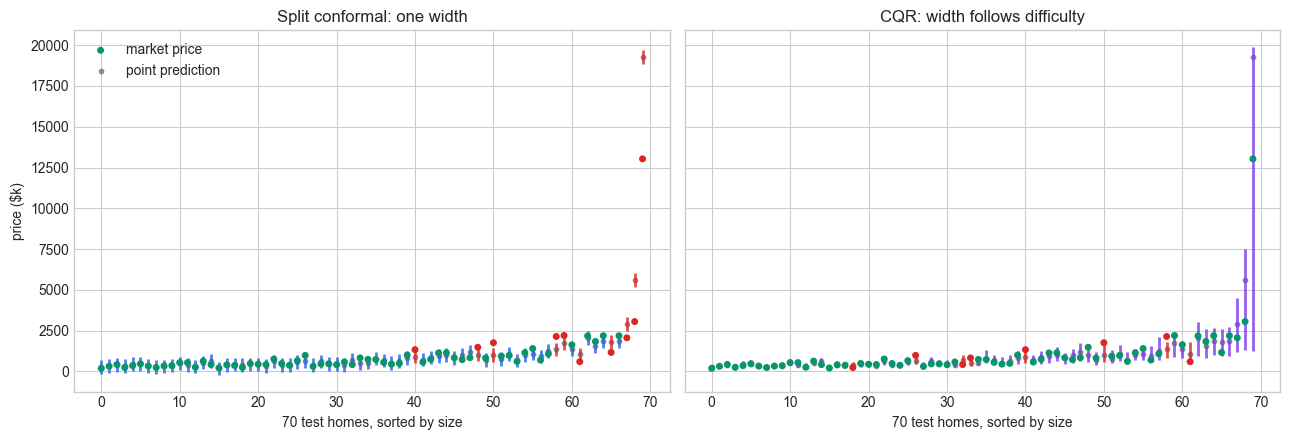

In [8]:
order = np.argsort(X_test[:, 0])
show = order[np.linspace(0, len(order) - 1, 70).astype(int)]
xs = np.arange(len(show))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, title, lo, hi, color in [
    (axes[0], "Split conformal: one width", lo_split, hi_split, BLUE),
    (axes[1], "CQR: width follows difficulty", lo_cqr, hi_cqr, PURPLE),
]:
    hit = (y_test[show] >= lo[show]) & (y_test[show] <= hi[show])
    ax.vlines(xs, lo[show], hi[show], color=np.where(hit, color, RED), alpha=0.8, linewidth=2)
    ax.scatter(xs, y_test[show], s=16, color=np.where(hit, GREEN, RED), zorder=3, label="market price")
    ax.scatter(xs, y_hat_test[show], s=10, color=GRAY, alpha=0.7, label="point prediction")
    ax.set_title(title)
    ax.set_xlabel("70 test homes, sorted by size")
axes[0].set_ylabel("price ($k)")
axes[0].legend(loc="upper left")
plt.tight_layout()


## 6. What to say in the regression review

**Strong version:**

> We use MAPIE for conformal regression, but we first reconciled its split-conformal
> output against our audited numpy implementation on the same train/calibration/test
> split. The library matched the finite-sample quantile exactly. We then compared the
> constant-width interval with CQR. Both met the marginal coverage target; CQR was chosen
> because its width better tracks the homes where pricing uncertainty is genuinely larger.

**Weak version:**

> We installed MAPIE and turned on prediction intervals.

The weak version is a dependency announcement. The strong version is an uncertainty
review.


### The one-line summary

MAPIE is worth using when it makes the audited recipe easier to maintain, but it does not
replace the review: coverage, width, and slices still decide whether a regression interval
is useful enough to ship.
